# Nonlinear Heat Conduction Problem with hyper-reduction, reduction and full order simulation

![Problem Schematic](problem_schematics.png)

## Environment Setup

### Directories

In [1]:
import sys
from pathlib import Path
import importlib

nb_folder = Path().resolve()
PROBLEM_NAME = nb_folder.name
parent_folder = nb_folder.parent
if str(parent_folder) not in sys.path:
    sys.path.insert(0, str(parent_folder))

### Standard Imports

In [2]:
#Standard Imports and class import
from skrom.utils.imports import *
from skrom.rom.rom_utils import *
from skrom.utils.reduced_basis.svd import svd_mode_selector
from skrom.rom.rom_error_est import *
from skrom.fom.fem_utils import load_domain
from skrom.utils.visualization.color_palette import set_color_palette
from skrom.utils.visualization.plot_utils import *
import skrom.problem_classes.static.master_class as master
problem_mod = importlib.import_module(f"{PROBLEM_NAME}.problem_def") #- this runs @register_problem

# SKROM ROM (Reduced Order Modeling) core classes
from skrom.rom.linear_form_rom import LinearFormROM
from skrom.rom.ecsw.hyperreduce import hyperreduce
import skrom.rom.deim.deim as deim_module
from problem_def import ProblemNonLinear
# Problem-specific linear forms
from linear_forms import R

PETSc available: True


### Plot Properties


In [3]:
# # Define a custom color palette with 19 distinct colors
import sci_mplstyle_package
set_color_palette();

## Full Order Simulation


In [4]:
# Control flag for expensive simulation generation

generate = True

# Conditional execution block for simulation data generation
if generate:
    # Create an instance of the non-linear heat conduction simulation
    sim = master.fom_simulation(num_snapshots=16)
    sim.run_simulation()


Snap 1/32 params=[  -1.34056737 -381.64152391]
Snap 2/32 params=[1.33670904e-01 5.46269177e+02]
Snap 3/32 params=[   2.33678542 -736.10590398]
Snap 4/32 params=[ -3.13721825 336.34030819]
Snap 5/32 params=[  -2.70393401 -941.82338007]
Snap 6/32 params=[  3.75442749 107.18345456]
Snap 7/32 params=[   1.70773276 -175.1935333 ]
Snap 8/32 params=[-7.50897683e-01  7.76160359e+02]
Snap 9/32 params=[-4.60427538e-01 -5.65826509e+02]
Snap 10/32 params=[  1.00307809 479.26379368]
Snap 11/32 params=[   3.45615254 -301.15011148]
Snap 12/32 params=[ -2.00709941 654.10076268]
Snap 13/32 params=[-3.58894328 -1.74078718]
Snap 14/32 params=[  2.88995083 914.44564983]
Snap 15/32 params=[ 5.93200743e-01 -8.65970163e+02]
Snap 16/32 params=[ -1.88591272 218.188392  ]
Snap 17/32 params=[ 3.89023145 91.47902764]
Snap 18/32 params=[  -0.5842438  -502.42842361]
Snap 19/32 params=[ -2.41957482 526.12717263]
Snap 20/32 params=[  1.11374594 -67.44816899]
Snap 21/32 params=[1.09735854e-01 8.51257060e+02]
Snap 22/3

### Load Simulation Data

In [5]:
#Load the ROM_data
current_dir = Path().resolve()
rom_dir = current_dir / "ROM_data"
fos_solutions, sim_data = load_rom_data(self=None, rom_data_dir=rom_dir)

[load_rom_data] loaded from D:\One_drive_folder\OneDrive - Indian Institute of Technology Indian School of Mines Dhanbad\IIT_ISM\RESEARCH\SCIKIT-ROM\scikit-rom\examples\heat_transfer\static\non_linear\problem_1_h\ROM_data


---

## Data Generation

### Generate Training Solution Dataset



In [6]:
# Convert parameter list to a NumPy array (representing system parameters)
# This contains the parameter values for each simulation run (e.g., thermal conductivity, 
# boundary conditions, material properties, etc.)
param_list = np.asarray(sim_data['param_list'])

# Load non-linear solutions from the full-order system
# NLS contains the high-fidelity finite element solutions for each parameter set
# Each row represents a complete solution snapshot (discretized spatial field)
NLS = np.asarray(fos_solutions)

# Split data into training and testing using predefined masks
# These boolean masks determine which snapshots are used for ROM training vs validation
train_mask, test_mask = sim_data['train_mask'], sim_data['test_mask']

# Apply masks to filter non-linear solutions for training and testing
# Training set: Used to construct the ROM basis functions and train the model
NLS_train = NLS[train_mask]  # Training snapshots with Dirichlet boundary conditions applied

# Testing set: Used to evaluate ROM accuracy and performance on unseen data
NLS_test = NLS[test_mask]    # Testing snapshots with Dirichlet boundary conditions applied

# Get the number of snapshots (parameter samples or time instances)
# N_snap: Total number of simulation snapshots available
# Second dimension: Number of degrees of freedom (DOFs) in the spatial discretization
N_snap, _ = np.shape(NLS)

# Display the total number of snapshots for verification
print(N_snap)  # Print the number of snapshots available

32


### Training Solution Snapshots


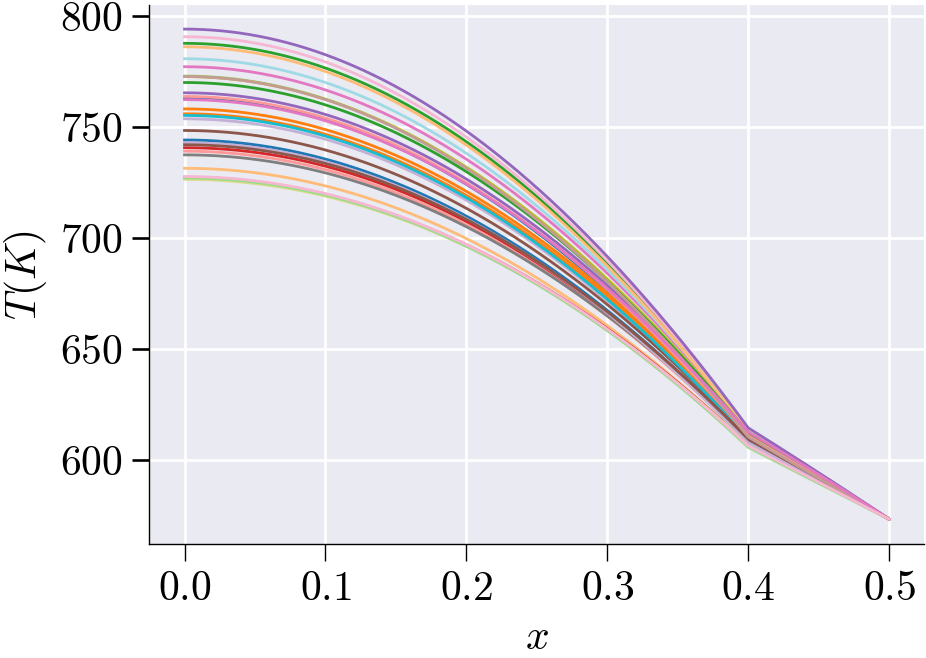

In [7]:
# Plot the computed temperature distribution
# Create a figure with specified dimensions (5x3.5 inches) for compact visualization
plt.figure(figsize=(5, 3.5))

# Extract spatial coordinates from the mesh data
# The mesh is stored as an object in sim_data, accessed via .item() to get the actual mesh
# mesh.p[0] contains the x-coordinates of the mesh nodes (1D spatial domain)
mesh_domain = sim_data['mesh'].item().p[0]

# Plot temperature profiles for all parameter combinations
# Loop through all non-linear solutions (each row is a complete temperature field)
for j in range(len(NLS)):
    # Plot each temperature distribution as a line
    # x-axis: spatial coordinates from the mesh
    # y-axis: temperature values at each spatial location
    # '-' specifies solid line style, markersize affects any markers
    plt.plot(mesh_domain, NLS[j], '-', markersize=2)

# Set axis labels with proper mathematical notation
plt.xlabel("$x$")        # Spatial coordinate (LaTeX formatting)
plt.ylabel("$T (K)$")    # Temperature in Kelvin (LaTeX formatting)

# Display the plot
plt.show()

### Mean Subtraction

In [8]:
# Compute the mean temperature field across all training snapshots
# This represents the "average" or "reference" temperature distribution
# Shape: [N_dof] - one mean value for each spatial degree of freedom
NLS_train_mean = np.mean(NLS_train, axis=0)

# Mean-center the training data by subtracting the mean field
# This creates fluctuations/deviations from the mean temperature distribution
# Shape: [N_train_snapshots, N_dof] - same as original but now mean-centered
# Each row now represents how much each snapshot deviates from the average
NLS_train_ms = NLS_train - NLS_train_mean

#We will use SVD on the mean subtracted matrix data

### Distribution of the training parameters

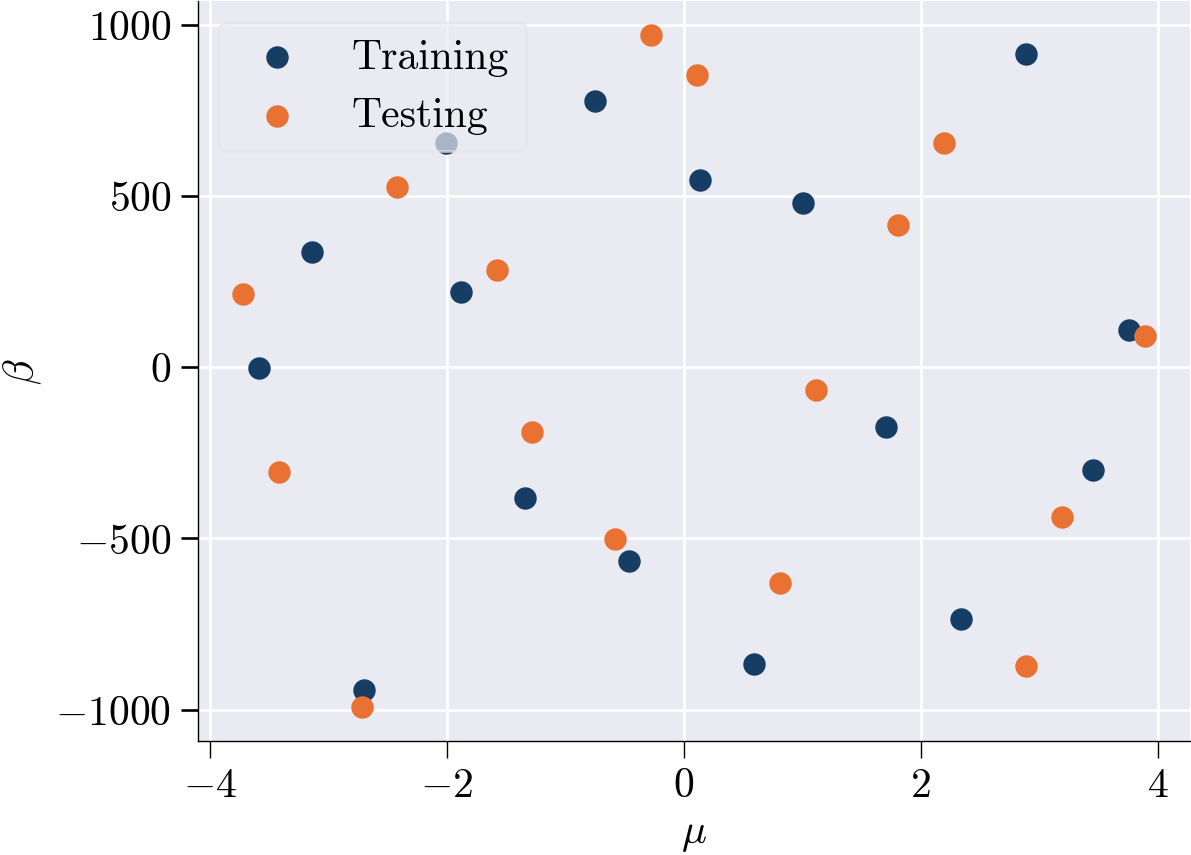

In [9]:
# Visualize the parameter space distribution for training and testing data
# Plot training parameter combinations (first 16 samples)
# Extract first and second parameter columns for 2D visualization
plt.scatter(param_list[:16][:, 0],    # First parameter (μ) for training samples which are the k_params 
           param_list[:16][:, 1],     # Second parameter (β) for training samples which are the q_params
           s=50,                      # Marker size
           c='#163e64',              # Dark blue color for training points
           label="Training")         # Legend label

# Plot testing parameter combinations (samples 17 and beyond)
plt.scatter(param_list[16:][:, 0],    # First parameter (μ) for testing samples
           param_list[16:][:, 1],     # Second parameter (β) for testing samples
           s=50,                      # Marker size (same as training)
           c='#e97132',              # Orange color for testing points
           label="Testing")          # Legend label

# Set axis labels using LaTeX formatting for mathematical notation
plt.xlabel("$\\mu$")        # First parameter (often material property, conductivity, etc.) this is the k_params
plt.ylabel("$\\beta$")     # Second parameter (often boundary condition, heat source, etc.) this is the q_params

# Add legend to distinguish between training and testing sets
plt.legend()

#See params and properties to see how these are used

### Training Snapshots after mean subtraction

Text(0.5, 0, '$x$')

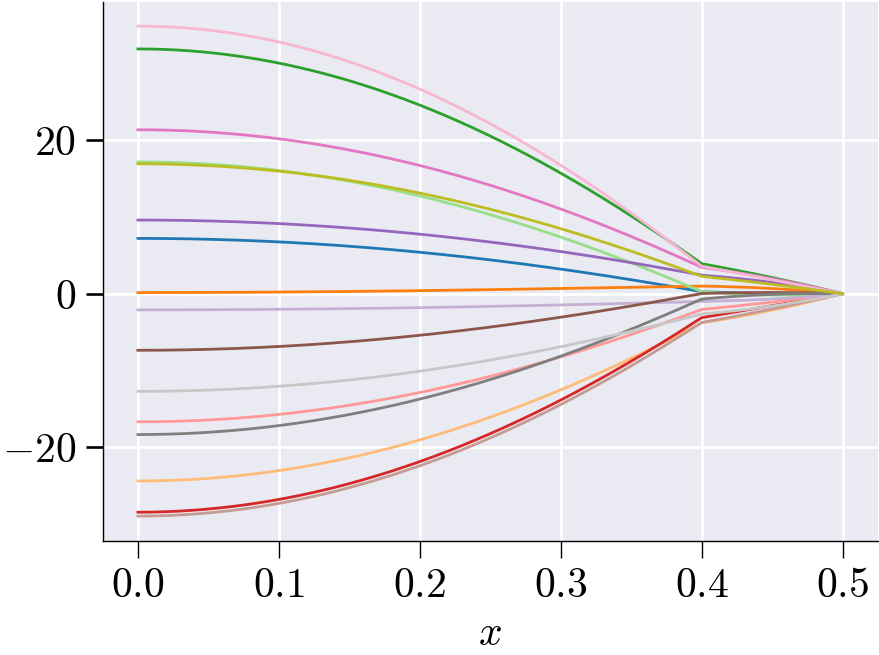

In [10]:
# Create figure with subplot for better control over the plot
fig, ax = plt.subplots(figsize=(5, 3.5))

# Apply the custom color cycle to this specific plot
# This ensures consistent coloring with the earlier defined palette


# Extract spatial coordinates (degrees of freedom locations) from the finite element basis
# These represent the x-coordinates where the temperature values are computed
mesh_domain = sim_data['basis'].item().doflocs[0]

# Plot all mean-centered temperature profiles from the training set
for i in range(len(NLS_train_ms)):
    # Plot each mean-centered temperature fluctuation profile
    # x-axis: spatial coordinate locations (DOF locations)
    # y-axis: temperature deviation from mean (fluctuations around zero)
    # Commented line shows alternative approach using different coordinate system
    # ax.plot(d.xi[0][:-1], LS_train_ms[i])
    ax.plot(mesh_domain, NLS_train_ms[i])

# Set x-axis label with mathematical formatting
plt.xlabel('$x$')  # Spatial coordinate

### Performing SVD on training snapshots

Number of modes selected: 4


Text(0.5, 0, 'POD modes ($k$)')

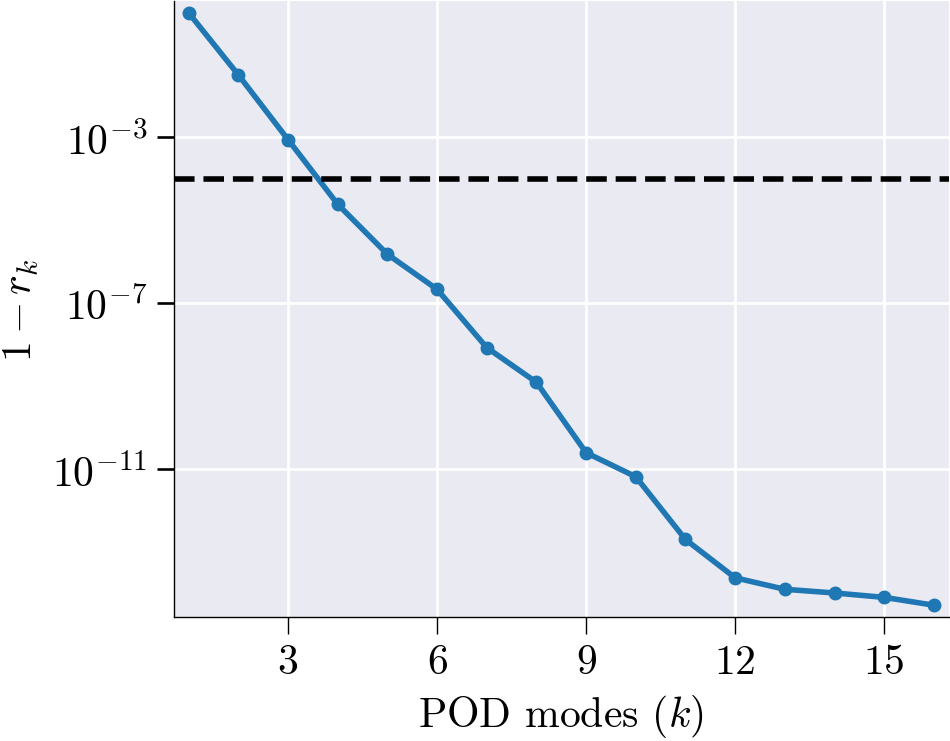

In [11]:
# Configure plot styling for POD analysis visualization
plt.rcParams['lines.markersize'] = 6      # Set marker size for data points
plt.rcParams['lines.linewidth'] = 2.0     # Set line thickness for better visibility

# Perform Singular Value Decomposition (SVD) for POD mode selection
# SVD decomposes the mean-centered training data to find optimal basis functions
n_sel, U = svd_mode_selector(NLS_train_ms,    # Input: mean-centered training snapshots
                            tolerance=1e-4,    # Convergence criterion for mode selection
                            modes=True)        # Return both number of modes and basis vectors


# Extract the selected POD basis vectors (spatial modes)
# V_sel contains the first n_sel most energetic POD modes
# Shape: [N_dof, n_sel] - each column is a spatial basis function
V_sel = U[:, :n_sel]  # This will be passed to the ROM simulation function

# Set axis labels for the POD energy plot (generated by svd_mode_selector)
plt.ylabel('$1-r_{k}$')           # Energy not captured by first k modes
plt.xlabel('POD modes ($k$)')     # Number of POD modes retained

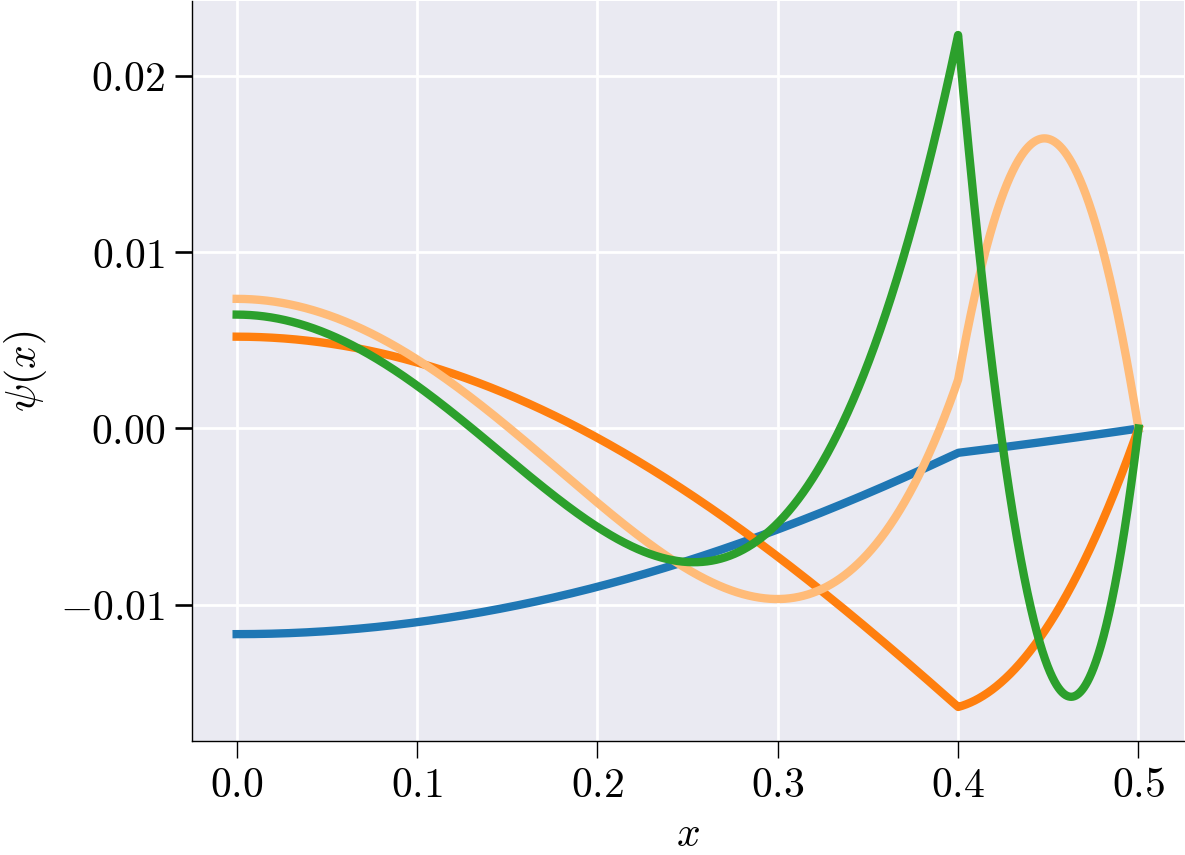

In [12]:
# Create figure and axis for POD modes visualization
fig, ax = plt.subplots()



# Plot all selected POD spatial modes
for i in range(n_sel):
    # Plot each POD mode as a function of spatial coordinate
    # x-axis: spatial locations (DOF coordinates)
    # y-axis: POD mode amplitude at each spatial location
    # lw=3: Use thick lines for better visibility of mode shapes
    plt.plot(mesh_domain, V_sel[:, i], lw=3)

# Set axis labels with mathematical notation
ax.set_xlabel('$x$')        # Spatial coordinate
ax.set_ylabel('$\\psi(x)$')  # POD mode amplitude (basis function value)

# Control the number of y-axis ticks for cleaner appearance
# nbins=5: Limit to approximately 5 major tick marks on y-axis
ax.yaxis.set_major_locator(MaxNLocator(nbins=5))

# Display the plot
plt.show()

---

## ROM Simulation


In [13]:
# Initialize the reduced-order model (ROM) simulation
#   V_sel : precomputed basis matrix (e.g., selected POD modes)
#   n_sel : number of basis vectors (modes) to retain in the ROM
rom = master.rom_simulation(V_sel=V_sel, n_sel = n_sel, train_ref=NLS_train_mean)

[load_rom_data] loaded from d:\One_drive_folder\OneDrive - Indian Institute of Technology Indian School of Mines Dhanbad\IIT_ISM\RESEARCH\SCIKIT-ROM\scikit-rom\examples\heat_transfer\static\non_linear\problem_1_h\ROM_data


In [14]:
# Run the reduced-order model (ROM) simulation.
# rom object will contain the NLS rom simulation solutions and other simulation aspects required by ROM such as the param_list etc.
generate = True
if generate:
    rom.run_rom_simulation();
#Returns the Newton iteration errors just like full order simulation

Snap 1/32 params=[ 3.89023145 91.47902764]
[ROM Newton] Iter  0, step norm = 2.200e+03
[ROM Newton] Iter  2, step norm = 3.008e-05
Snap 2/32 params=[  -0.5842438  -502.42842361]
[ROM Newton] Iter  0, step norm = 9.470e+02
[ROM Newton] Iter  2, step norm = 6.103e-07
Snap 3/32 params=[ -2.41957482 526.12717263]
[ROM Newton] Iter  0, step norm = 2.790e+03
[ROM Newton] Iter  2, step norm = 1.611e-04
Snap 4/32 params=[  1.11374594 -67.44816899]
[ROM Newton] Iter  0, step norm = 1.002e+03
[ROM Newton] Iter  2, step norm = 2.259e-07
Snap 5/32 params=[1.09735854e-01 8.51257060e+02]
[ROM Newton] Iter  0, step norm = 1.180e+03
[ROM Newton] Iter  2, step norm = 7.155e-06
Snap 6/32 params=[  -3.41553612 -305.17523549]
[ROM Newton] Iter  0, step norm = 3.168e+03
[ROM Newton] Iter  2, step norm = 2.989e-04
Snap 7/32 params=[ -1.58045687 281.99134767]
[ROM Newton] Iter  0, step norm = 1.939e+03
[ROM Newton] Iter  2, step norm = 4.037e-05
Snap 8/32 params=[   2.88647313 -874.09356423]
[ROM Newton] Ite

In [15]:
#Assign values for the statistics
NLS_rom = np.asarray(rom.rom_solutions)
ROM_speed_up = rom.speed_up
ROM_speed_up=ROM_speed_up
ROM_relative_error = rom.rom_error

### ROM solution vs. Full order solution performance statistics 

ROM Accuracy Report

Global Errors:
L2 Error:                 1.0530e-03
Relative L2 Error:        4.7930e-08
L∞ Error:                 1.2431e-04
Relative L∞ Error:        1.5655e-07
RMSE:                     3.2906e-05
MAE:                      2.1685e-05

Statistical Fit:
R² Score:                 1.0000
Explained Variance:       1.0000

Error Distribution:
Median Error:             -9.2047e-08
95th Percentile Error:    7.5867e-05

Time/Parameter-Dependent Errors:
Average Rel L2 Error over time/parameter: 2.2462e-09
Max Rel L2 Error over time/parameter: 6.9475e-09
Min Rel L2 Error over time/parameter: 4.2539e-10
―――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――

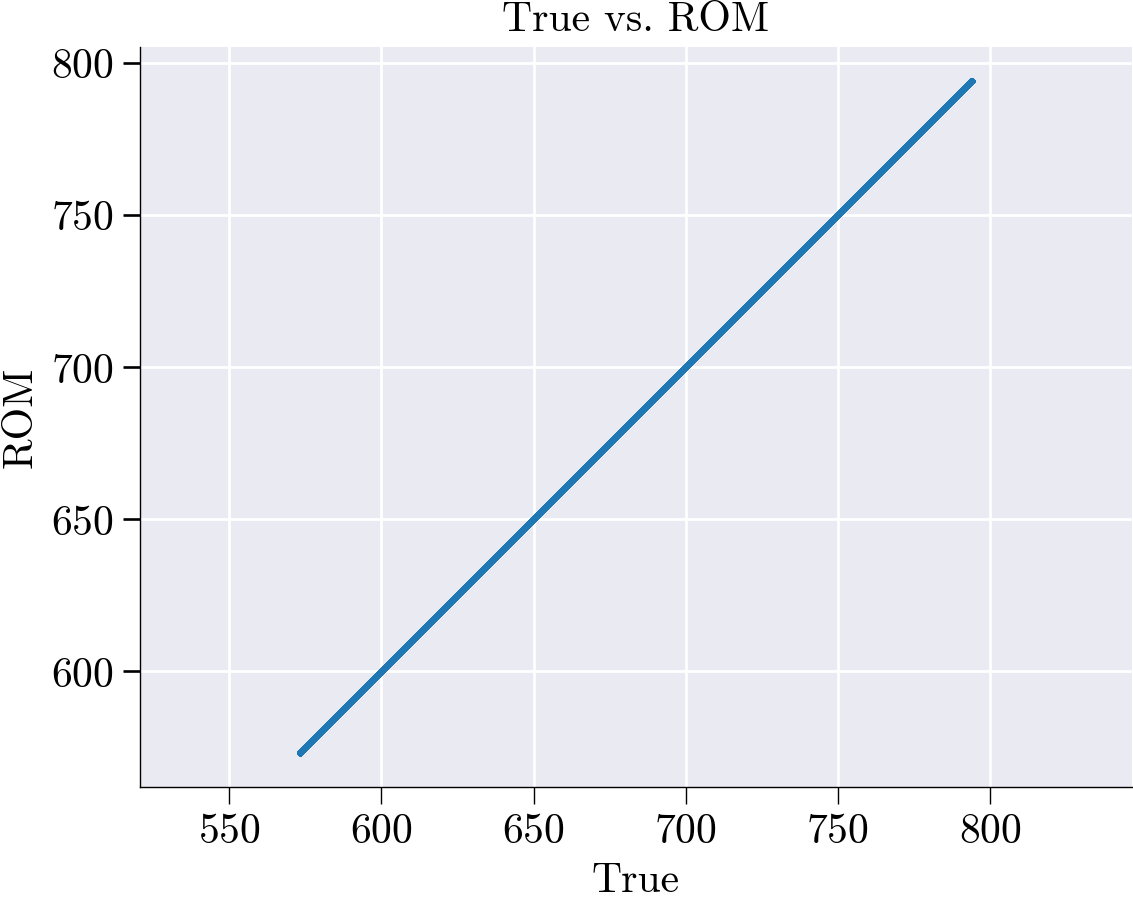

spatial_shape not given → skipping spatial snapshots.
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


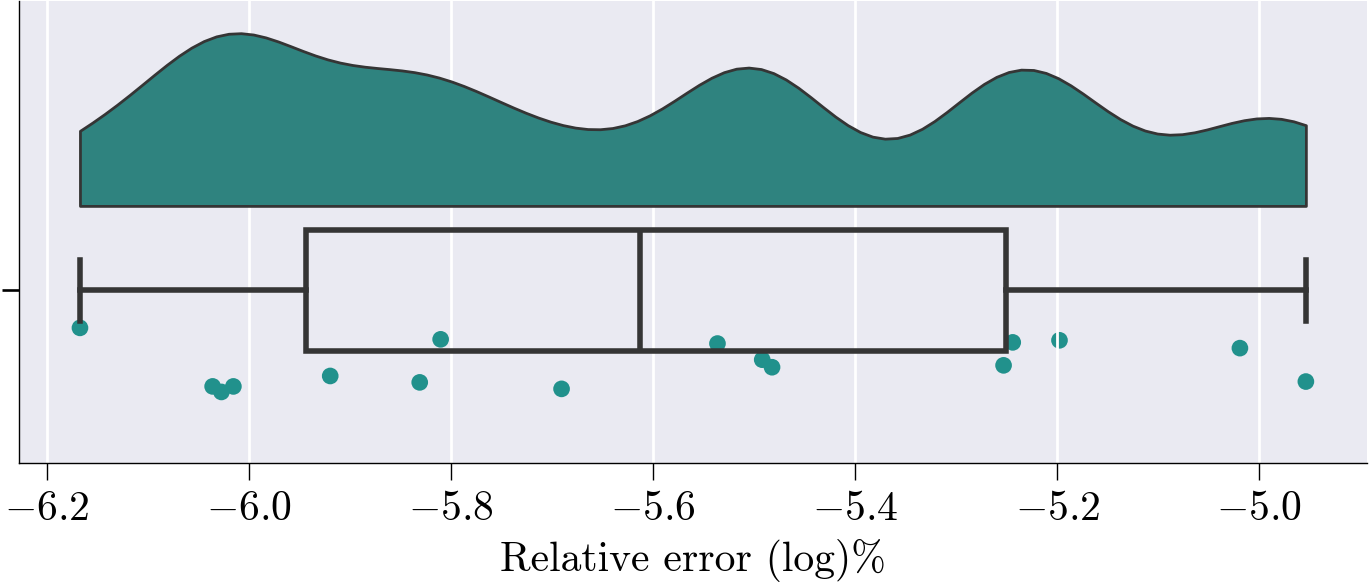

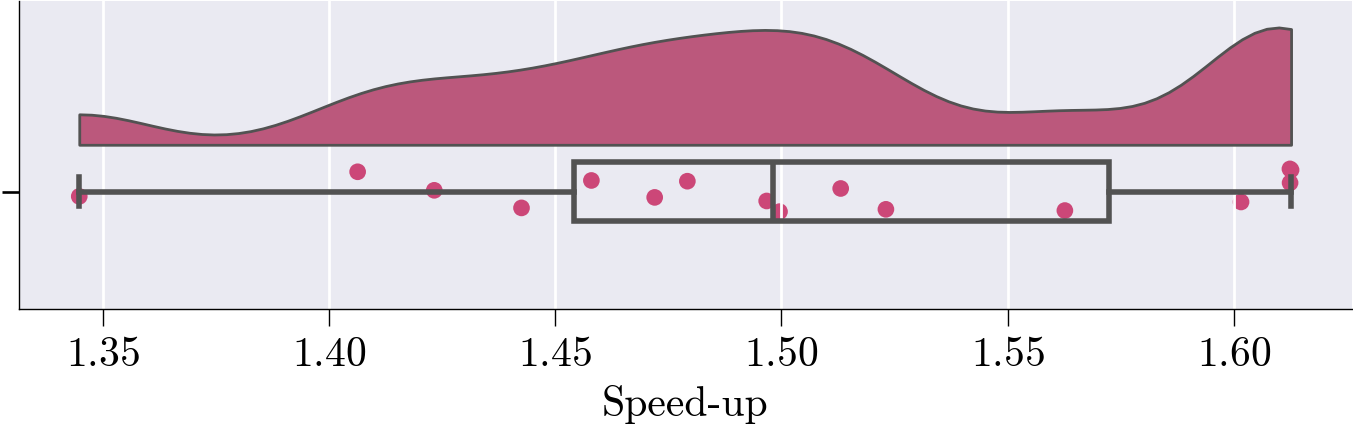

In [16]:
# --- Standard ROM error analysis ---

# Compute a flat matrix of error metrics comparing true nonlinear solutions to ROM approximations
matrix = compute_rom_error_metrics_flat(NLS_test, NLS_rom)

# Produce a text-based report summarizing these error metrics
generate_rom_error_report(matrix)

# Plot diagnostic figures: error vs. speed-up for the standard ROM
plot_rom_error_diagnostics_flat(
    NLS_test,               # full-order (true) solution snapshots
    NLS_rom,                # ROM-generated solution snapshots
    ROM_relative_error,     # precomputed relative error of the ROM
    ROM_speed_up,           # precomputed speed-up factor of the ROM
    sim_axis=['True', 'ROM'], 
    metrics=matrix          # the matrix of error metrics just computed
)


---

## Hyper ROM Simulation


### 1. ECSW

#### Mesh Sampling


In [17]:
prob = ProblemNonLinear()
sim_data['free_dofs'] = prob.domain()['free_dofs']
sim_data['dirichlet_boundary_dofs'] = prob.domain()['dirichlet_boundary_dofs']
sim_data['global_mask'] = prob.domain()['global_mask']
# Extract free degrees of freedom (DOFs) 
free_dofs = sim_data['free_dofs']
basis = sim_data['basis'].item()


In [18]:
# Create the ROM residual linear form object
# This represents the linear form R(u,v) in the weak formulation of the PDE
Residual = LinearFormROM(R,                    # Linear form function from problem definition
                         basis,                 # Finite element basis functions
                         V_sel,                 # Selected POD modes (reduced basis)
                         free_dofs=free_dofs)   # Free DOFs (excluding Dirichlet boundaries)

# Extract parameter values corresponding to training snapshots
# Uses the boolean mask to get only the parameter combinations used for training
training_params = param_list[train_mask]

In [19]:
# Collect residual evaluations for all training snapshots
# This creates the dataset needed for hyperreduction of nonlinear ROM terms
q_mus = collect_residuals(
    NLS_train_ms,         # Mean-centered training snapshots
    NLS_train_mean,       # Mean temperature field
    V_sel,                # Selected POD basis modes
    reconstruct_solution, # Solution reconstruction function
    Residual,             # ROM residual operator
    training_params,
    prob.assemble_kwargs,
    extra_kwargs = dict(global_mask = sim_data['global_mask'] )
)

# Display the shape of collected residuals for verification
# Shape should be: (n_training_snapshots * SVD components, n_residual_evaluation_points)
print(q_mus.shape)

#Output should be 16(for training snapshots) * 5(SVD components selected) = 80

(64, 16383)


#### Performing the SVD on snapshots

Performing SVD...
magnitude of d_q: 127.99609368792338


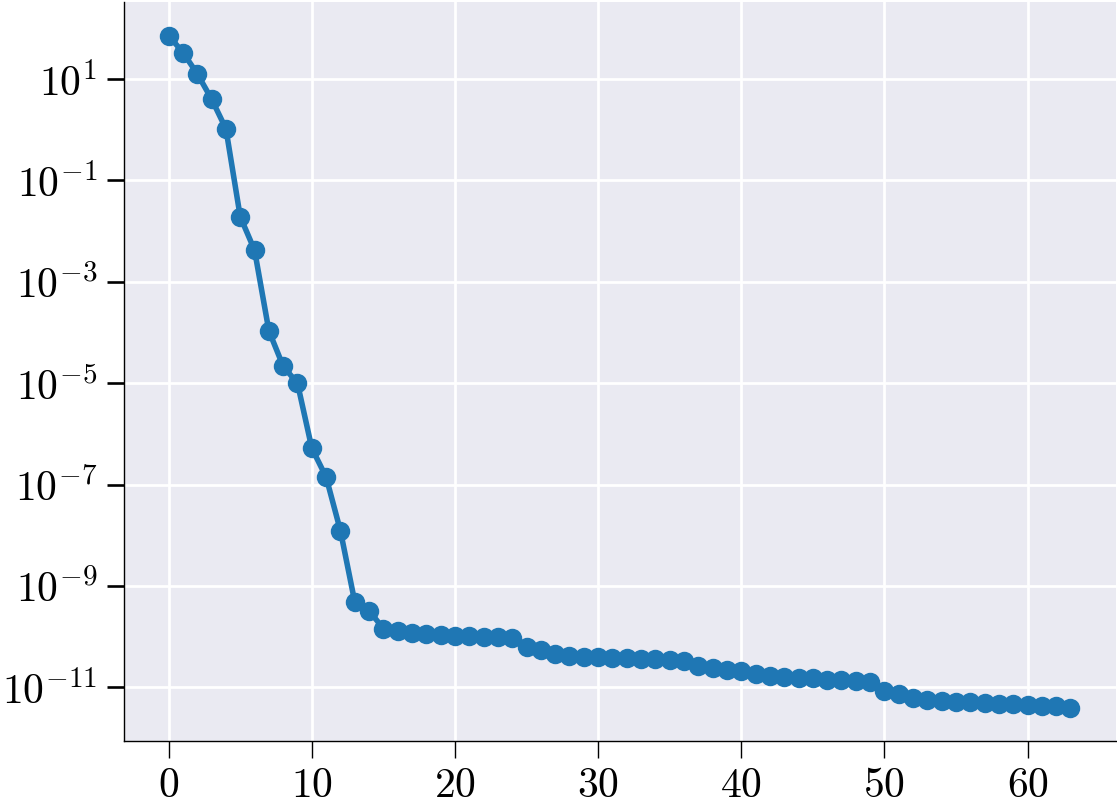

In [20]:
print("Performing SVD...")
# Performs Singular Value Decomposition on q_mus matrix
# Returns U (left singular vectors), s (singular values), Vh (right singular vectors transposed)
Uh, s, Vh = np.linalg.svd(q_mus, full_matrices=False)

# Plots singular values on a logarithmic y-scale to visualize their decay
# This helps identify the effective rank/dimensionality of the matrix
plt.semilogy(s, 'o-')

# Takes the first 20 right singular vectors (rows of Vh)
# This creates a reduced basis capturing the most significant modes
V_q_eff = Vh[:20]

# Computes a weighted combination of the basis vectors
# Each basis vector is weighted equally (multiplied by 1)
# This essentially sums all 20 basis vectors
d_q = V_q_eff @ np.ones(V_q_eff.shape[1])

# Outputs the L2 norm of the resulting vector
# This gives a sense of the magnitude of the combined basis representation
print("magnitude of d_q:", np.linalg.norm(d_q))

#### NNLS matrix

In [21]:
# Solve the non-negative least squares (NNLS) problem using hyperreduce
#   V_q_eff   : effective basis matrix
#   verbosity : level of log output (2 = detailed)
#   const_tol : tolerance for column selection
#   zero_tol  : tolerance to treat values as zero
#   plot      : disable plotting
x_nnls_m, err = hyperreduce(
    V_q_eff,
    verbosity=2,
    const_tol=1e-8,
    zero_tol=1e-8,
    plot=False
)

# Compute and print the relative NNLS reconstruction error:
#   ‖q_mus·(x_nnls_m – 1)‖ / ‖q_mus·1‖
rel_error = np.linalg.norm(q_mus @ (x_nnls_m - np.ones_like(x_nnls_m)))
rel_error /= np.linalg.norm(q_mus @ np.ones_like(x_nnls_m))
print("NNLS error:", rel_error)

NNLSSolver init (Sequential Version)

Starting NNLS solve...
0 0 20 16383 0 1.266445327078478e+02 1.279960936879234e+02
1 1 20 16383 1 1.215326393670338e+02 1.258671649651614e+02
2 2 20 16383 2 1.201044018818882e+02 1.249820612507927e+02
3 3 20 16383 3 1.184121198348209e+02 1.238861746477756e+02
4 4 20 16383 4 1.156087121447549e+02 1.224577089389883e+02
5 5 20 16383 5 1.107442369838787e+02 1.197037845900319e+02
6 6 20 16383 6 1.068337163051426e+02 1.176627788578034e+02
7 7 20 16383 7 1.008710717937750e+02 1.146579457212664e+02
8 8 20 16383 8 8.722217956067657e+01 1.062421777067439e+02
9 9 20 16383 9 5.598462164975862e+01 8.679900326078177e+01
10 10 20 16383 10 3.576502532565547e+01 6.348141645742262e+01
11 11 20 16383 11 1.649482641804880e+01 3.375550948920250e+01
12 12 20 16383 12 1.451284676725494e+01 2.844441321216846e+01
13 13 20 16383 13 6.392830334692436e+00 1.360978737490359e+01
14 14 20 16383 14 5.189250870129609e+00 1.092166955449082e+01
15 15 20 16383 15 5.508851747018552e+00

#### Plot Reduced Meshes with weights

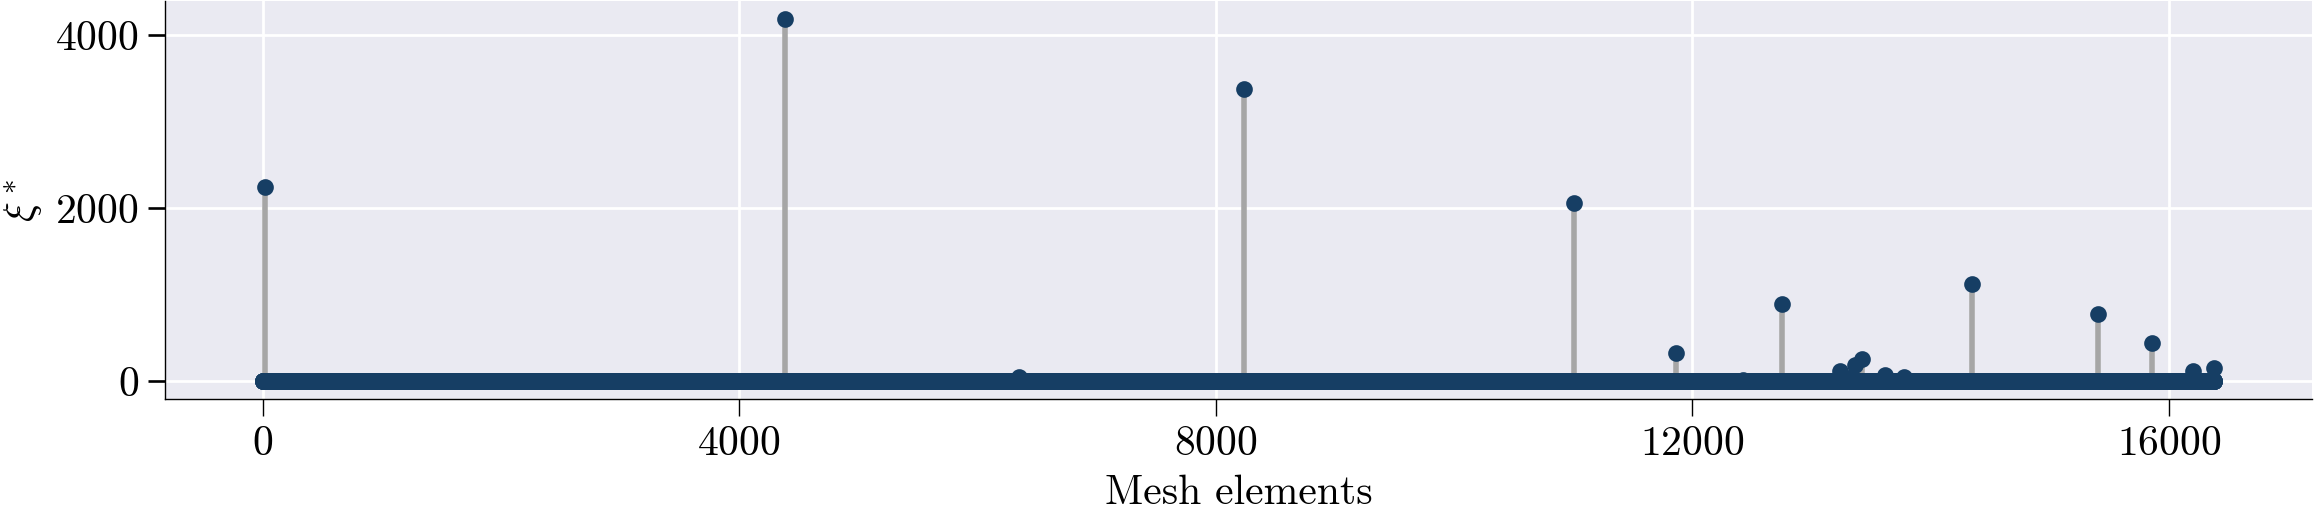

In [22]:
fig, ax = plot_ecsw_weights(x_nnls_m)

### Run HyperROM simulation


In [23]:
# Run the hyper-reduced ROM simulation using the NNLS weights
#   x_nnls_m : array of non-negative least squares coefficients,
#              used here to weight the reduced basis contributions
#rom will contain the hyper_rom solution as an attribute
rom.run_hyper_rom_simulation_ecsw(x_nnls_m);
#rom.run_hyper_rom_simulation(x_nnls_m)

Snap 1/16 params=[ 3.89023145 91.47902764]
[ROM Newton] Iter  0, step norm = 2.313e+03
[ROM Newton] Iter  3, step norm = 8.750e-03
Snap 2/16 params=[  -0.5842438  -502.42842361]
[ROM Newton] Iter  0, step norm = 4.971e+02
[ROM Newton] Iter  4, step norm = 6.516e-04
Snap 3/16 params=[ -2.41957482 526.12717263]
[ROM Newton] Iter  0, step norm = 2.457e+03
[ROM Newton] Iter  4, step norm = 3.064e-03
Snap 4/16 params=[  1.11374594 -67.44816899]
[ROM Newton] Iter  0, step norm = 8.815e+02
[ROM Newton] Iter  4, step norm = 1.725e-04
Snap 5/16 params=[1.09735854e-01 8.51257060e+02]
[ROM Newton] Iter  0, step norm = 7.299e+02
[ROM Newton] Iter  4, step norm = 6.559e-04
Snap 6/16 params=[  -3.41553612 -305.17523549]
[ROM Newton] Iter  0, step norm = 2.858e+03
[ROM Newton] Iter  4, step norm = 4.742e-03
Snap 7/16 params=[ -1.58045687 281.99134767]
[ROM Newton] Iter  0, step norm = 1.569e+03
[ROM Newton] Iter  4, step norm = 1.706e-03
Snap 8/16 params=[   2.88647313 -874.09356423]
[ROM Newton] Ite

In [24]:
# Convert the list of nonlinear hyper-ROM solutions into a NumPy array
NLS_hyper_rom = np.asarray(rom.hyper_rom_solutions)

# Retrieve the raw speed-up factors computed by the ROM
hyper_ROM_speed_up = rom.hyper_speed_up

# Drop the first element (often the full-order baseline) to analyze only relative speed-ups
hyper_ROM_speed_up = hyper_ROM_speed_up[1:]

# Fetch the relative error of the hyper-reduced ROM from the ROM object
hyper_ROM_relative_error = rom.hyper_rom_error

### Hyper ROM vs Full order solution performance statistics


ROM Accuracy Report

Global Errors:
L2 Error:                 1.0534e-03
Relative L2 Error:        4.7947e-08
L∞ Error:                 1.2478e-04
Relative L∞ Error:        1.5715e-07
RMSE:                     3.2918e-05
MAE:                      2.1693e-05

Statistical Fit:
R² Score:                 1.0000
Explained Variance:       1.0000

Error Distribution:
Median Error:             -9.1373e-08
95th Percentile Error:    7.5873e-05

Time/Parameter-Dependent Errors:
Average Rel L2 Error over time/parameter: 2.2473e-09
Max Rel L2 Error over time/parameter: 6.9508e-09
Min Rel L2 Error over time/parameter: 4.2277e-10
―――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――

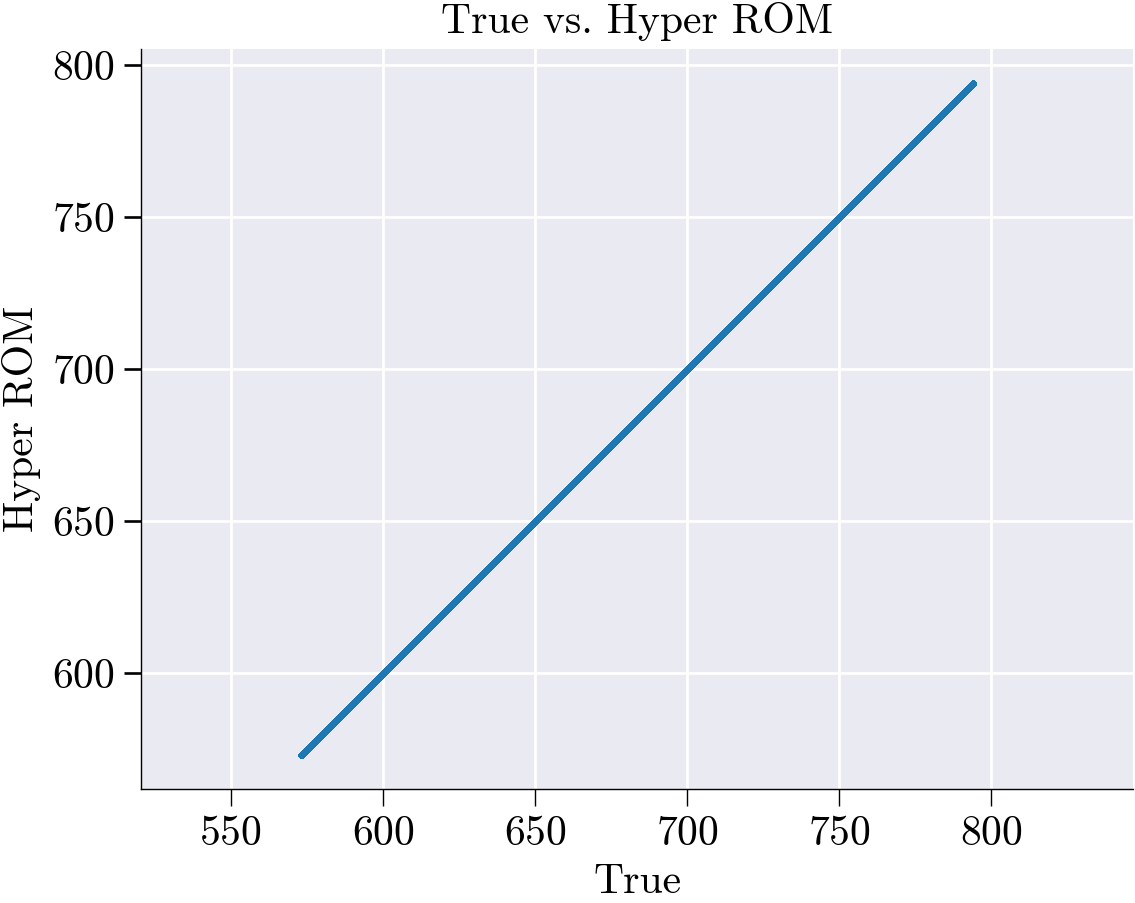

spatial_shape not given → skipping spatial snapshots.
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


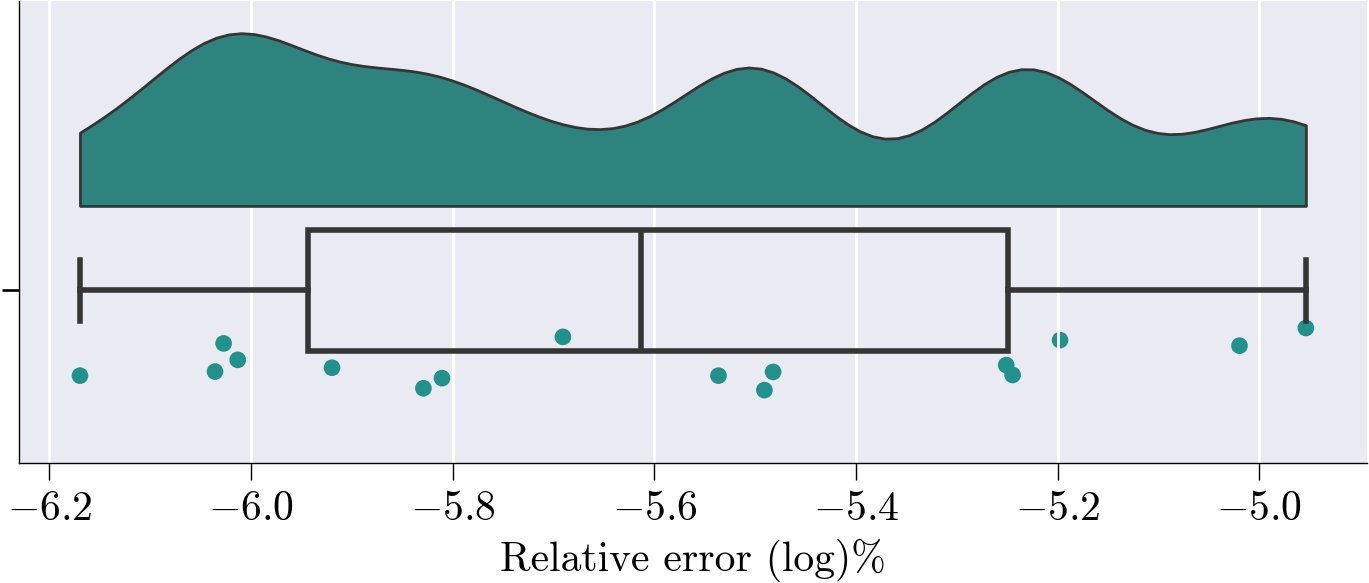

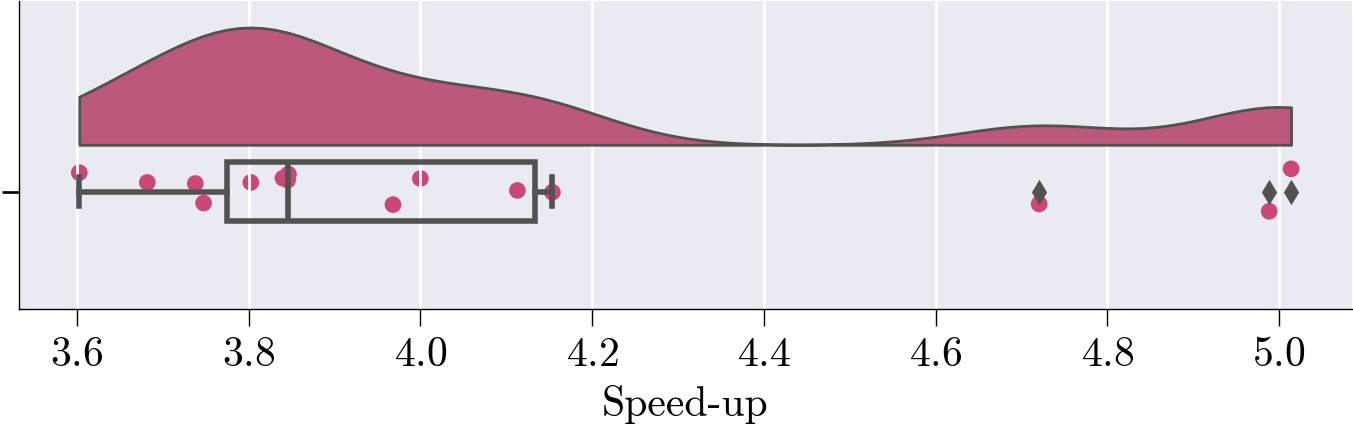

In [25]:
# --- Hyper-reduced ROM error analysis ---

# Compute a flat matrix of error metrics comparing true nonlinear solutions to hyper-ROM approximations
matrix = compute_rom_error_metrics_flat(NLS_test, NLS_hyper_rom)

# Produce a text-based report summarizing these hyper-ROM error metrics
generate_rom_error_report(matrix)

# Plot diagnostic figures: error vs. speed-up for the hyper-reduced ROM
plot_rom_error_diagnostics_flat(
    NLS_test,                   # full-order (true) solution snapshots
    NLS_hyper_rom,              # hyper-ROM-generated solution snapshots
    hyper_ROM_relative_error,   # precomputed relative error of the hyper-ROM
    hyper_ROM_speed_up,         # precomputed speed-up factor of the hyper-ROM
    sim_axis=['True', 'Hyper ROM'], 
    metrics=matrix              # the matrix of error metrics just computed
)



---

### 2. DEIM

In [26]:
prob.basis = basis
prob.global_mask = sim_data['global_mask']
prob.mesh  = sim_data['mesh'].item()
F_nl = compute_nonlinear_snapshots(
    non_linear_func=prob.f_nl,
    fos_solutions=fos_solutions[train_mask],
    param_list=param_list[train_mask]
)

Text(0, 0.5, '$q(T,\\beta)$')

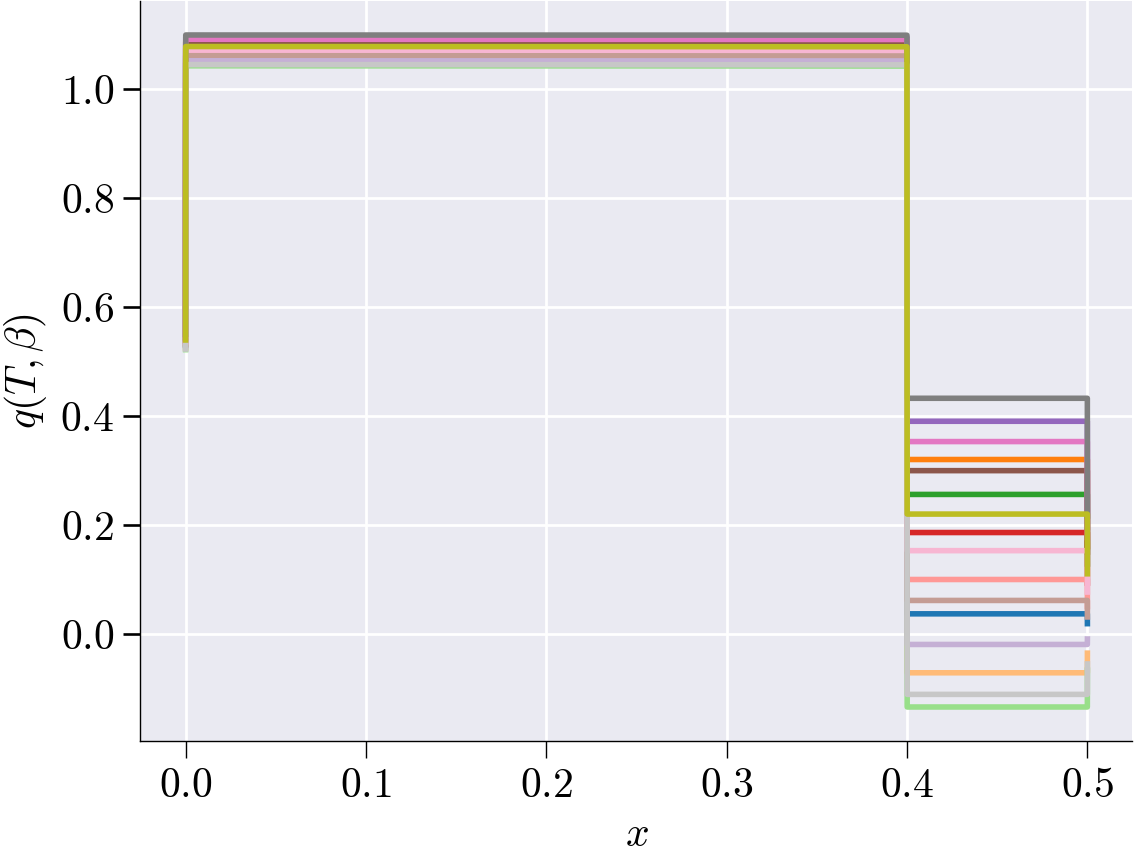

In [27]:
fig, ax = plt.subplots()
for i in range(len(F_nl)):
    ax.plot(mesh_domain, F_nl[i])
plt.xlabel('$x$')
plt.ylabel('$q(T,\\beta)$')

Selected modes: 4


Text(0.5, 0, 'POD modes ($r$)')

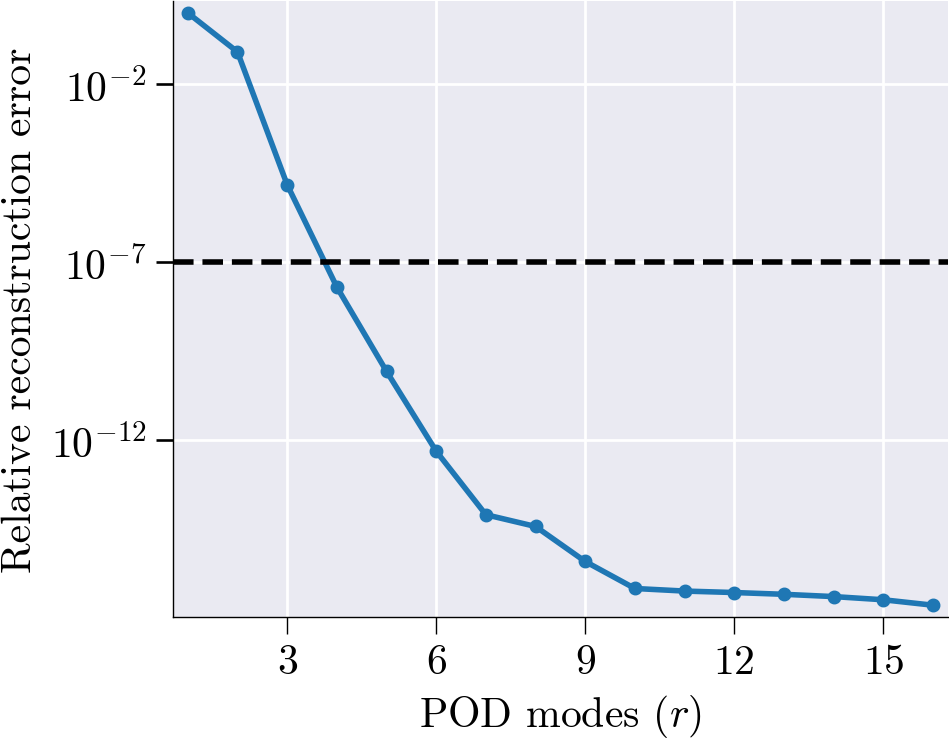

In [28]:
# Force snapshots
deim_class = deim_module.deim(prob.mesh, F_nl, V_sel, tol_f=1e-7, extra_modes = 0)

tic_h_setup_b = time.time()
deim_mat, sampled_rows = deim_class.select_elems()
toc_h_setup_b = time.time()

xi_deim = deim_class.xi
plt.xlabel('POD modes ($r$)')

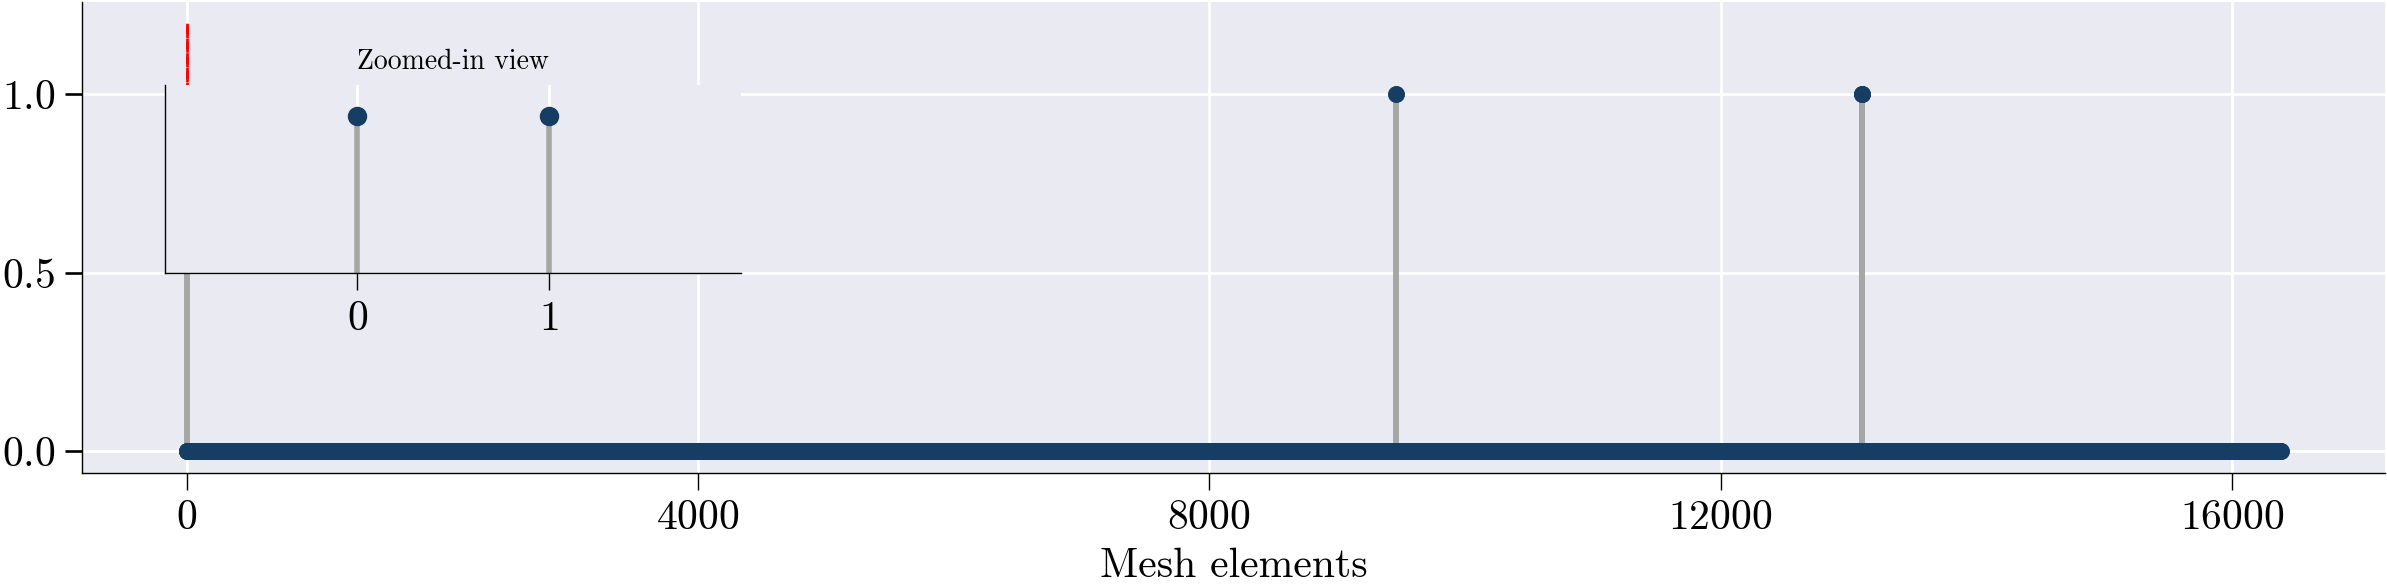

In [29]:
fig, ax = plot_deim_weights(xi_deim.copy())

In [30]:
rom.run_hyper_rom_simulation_deim(z = xi_deim, deim_mat = deim_mat, sampled_rows = sampled_rows);

Snap 1/32 params=[ 3.89023145 91.47902764]
[ROM Newton] Iter  0, step norm = 1.532e+03
[ROM Newton] Iter  5, step norm = 9.714e-03
Snap 2/32 params=[  -0.5842438  -502.42842361]
[ROM Newton] Iter  0, step norm = 1.731e+03
[ROM Newton] Iter  6, step norm = 3.017e-03
Snap 3/32 params=[ -2.41957482 526.12717263]
[ROM Newton] Iter  0, step norm = 4.084e+03
[ROM Newton] Iter  7, step norm = 1.416e-03
Snap 4/32 params=[  1.11374594 -67.44816899]
[ROM Newton] Iter  0, step norm = 9.669e+02
[ROM Newton] Iter  7, step norm = 5.952e-03
Snap 5/32 params=[1.09735854e-01 8.51257060e+02]
[ROM Newton] Iter  0, step norm = 2.004e+03
[ROM Newton] Iter  6, step norm = 4.670e-03
Snap 6/32 params=[  -3.41553612 -305.17523549]
[ROM Newton] Iter  0, step norm = 4.610e+03
[ROM Newton] Iter  8, step norm = 1.749e-03
Snap 7/32 params=[ -1.58045687 281.99134767]
[ROM Newton] Iter  0, step norm = 3.076e+03
[ROM Newton] Iter  6, step norm = 6.333e-03
Snap 8/32 params=[   2.88647313 -874.09356423]
[ROM Newton] Ite

In [31]:
# Convert the list of nonlinear hyper-ROM solutions into a NumPy array
NLS_hyper_rom = np.asarray(rom.hyper_rom_solutions)

# Retrieve the raw speed-up factors computed by the ROM
hyper_ROM_speed_up = rom.hyper_speed_up

# Drop the first element (often the full-order baseline) to analyze only relative speed-ups
hyper_ROM_speed_up = hyper_ROM_speed_up[1:]

# Fetch the relative error of the hyper-reduced ROM from the ROM object
hyper_ROM_relative_error = rom.hyper_rom_error

ROM Accuracy Report

Global Errors:
L2 Error:                 5.1465e-01
Relative L2 Error:        2.3425e-05
L∞ Error:                 4.1900e-02
Relative L∞ Error:        5.2769e-05
RMSE:                     1.6083e-02
MAE:                      1.1049e-02

Statistical Fit:
R² Score:                 1.0000
Explained Variance:       1.0000

Error Distribution:
Median Error:             2.7912e-04
95th Percentile Error:    3.9543e-02

Time/Parameter-Dependent Errors:
Average Rel L2 Error over time/parameter: 1.0379e-06
Max Rel L2 Error over time/parameter: 3.4324e-06
Min Rel L2 Error over time/parameter: 2.8401e-09
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――

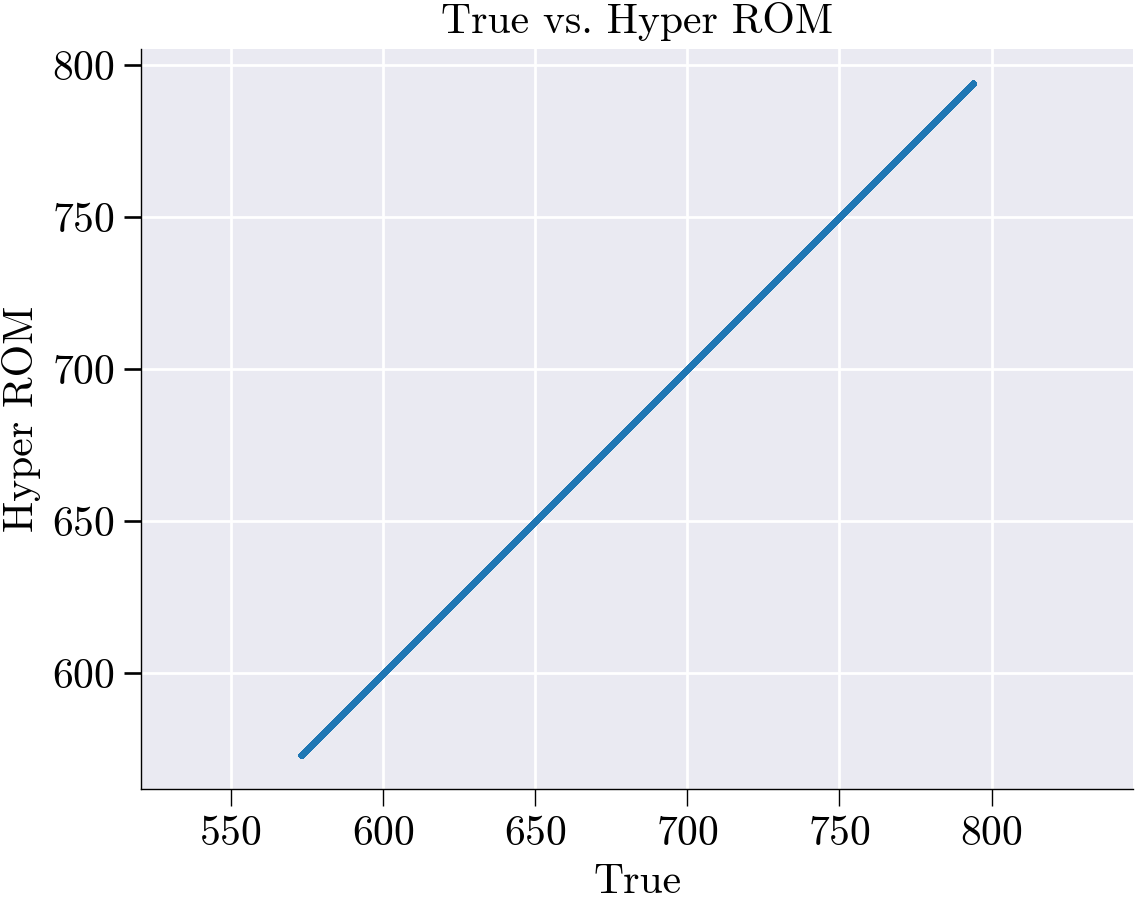

spatial_shape not given → skipping spatial snapshots.
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


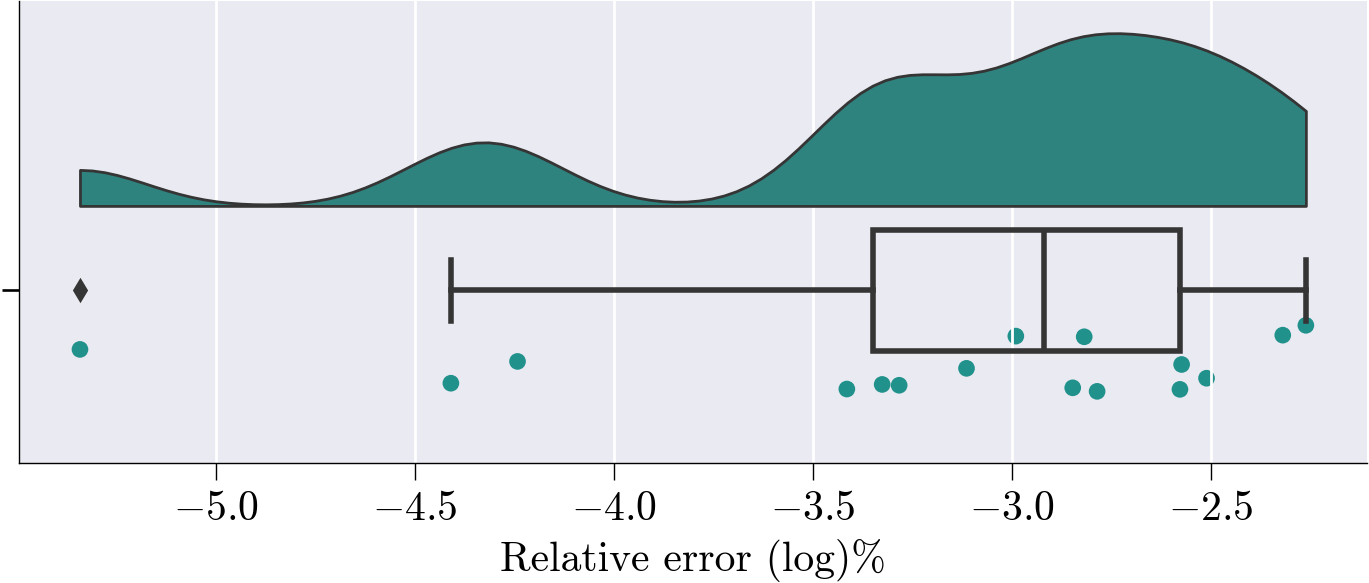

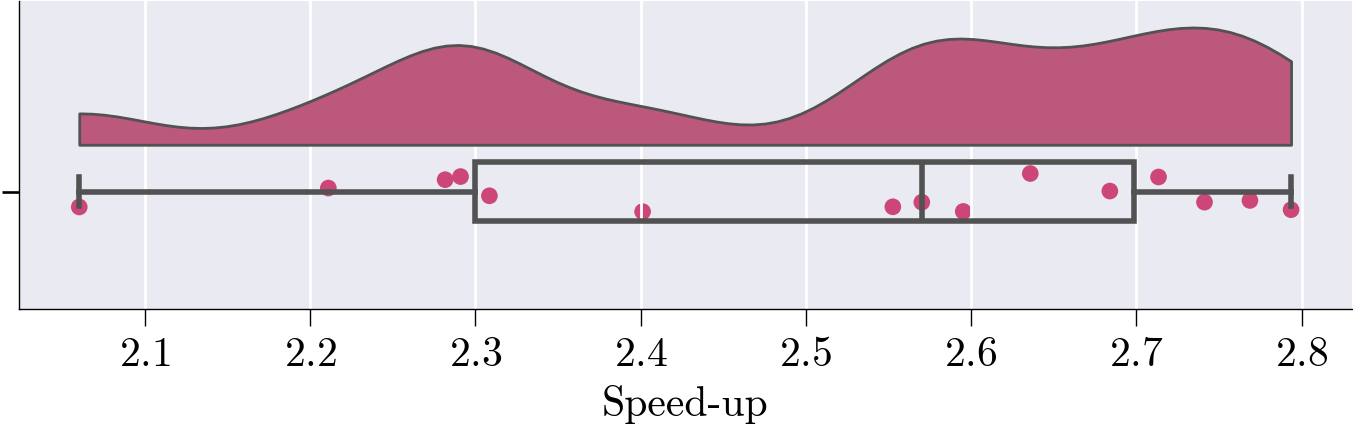

In [32]:
# --- Hyper-reduced ROM error analysis ---

# Compute a flat matrix of error metrics comparing true nonlinear solutions to hyper-ROM approximations
matrix = compute_rom_error_metrics_flat(NLS_test, NLS_hyper_rom)

# Produce a text-based report summarizing these hyper-ROM error metrics
generate_rom_error_report(matrix)

# Plot diagnostic figures: error vs. speed-up for the hyper-reduced ROM
plot_rom_error_diagnostics_flat(
    NLS_test,                   # full-order (true) solution snapshots
    NLS_hyper_rom,              # hyper-ROM-generated solution snapshots
    hyper_ROM_relative_error,   # precomputed relative error of the hyper-ROM
    hyper_ROM_speed_up,         # precomputed speed-up factor of the hyper-ROM
    sim_axis=['True', 'Hyper ROM'], 
    metrics=matrix              # the matrix of error metrics just computed
)


## ECM workflow

This appended section mirrors the existing ECSW workflow, but collects residual snapshots at the element–Gauss-point level and calls the ECM online solver path.


In [33]:
from skrom.rom.rom_utils import collect_residuals_ecm
from skrom.rom.ecm import train_ecm

In [34]:
Residual_ecm = LinearFormROM(R, basis, V_sel, free_dofs=free_dofs)
ecm_data = train_ecm.ECM_from_skrom(
    NLS_train_ms=NLS_train_ms,
    NLS_train_mean=NLS_train_mean,
    V_sel=V_sel,
    reconstruct_solution=reconstruct_solution,
    Residual=Residual_ecm,
    training_params=training_params,
    assemble_kwargs=prob.assemble_kwargs,
    basis=basis,
    extra_kwargs=dict(global_mask=sim_data["global_mask"]),
    tol=1e-8,
    plot=False,
    svd_rank = 30
)


k = 1, m = 1, error n(res)/n(b) (%) = 98.11146381608559,  Actual error % = 98.11146381608559 
k = 2, m = 2, error n(res)/n(b) (%) = 97.34753395105213,  Actual error % = 97.34753395105213 
k = 3, m = 3, error n(res)/n(b) (%) = 92.29531787045279,  Actual error % = 92.29531787045279 
k = 4, m = 4, error n(res)/n(b) (%) = 83.1965415147169,  Actual error % = 83.1965415147169 
k = 5, m = 5, error n(res)/n(b) (%) = 68.55933436807386,  Actual error % = 68.55933436807386 
k = 6, m = 6, error n(res)/n(b) (%) = 50.551873309382735,  Actual error % = 50.551873309382735 
k = 7, m = 7, error n(res)/n(b) (%) = 50.02526514343549,  Actual error % = 50.02526514343549 
k = 8, m = 8, error n(res)/n(b) (%) = 49.29433170005357,  Actual error % = 49.29433170005357 
k = 9, m = 9, error n(res)/n(b) (%) = 42.78182038078298,  Actual error % = 42.78182038078298 
k = 10, m = 10, error n(res)/n(b) (%) = 32.282029691303045,  Actual error % = 32.282029691303045 
k = 11, m = 11, error n(res)/n(b) (%) = 29.0174919479859

D:\One_drive_folder\OneDrive - Indian Institute of Technology Indian School of Mines Dhanbad\IIT_ISM\RESEARCH\SCIKIT-ROM\scikit-rom\src\skrom\rom\ecm\empirical_cubature_method.py:147: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  alpha = np.linalg.lstsq(self.G[:, [i]], self.b)[0]


In [35]:
gauss_weight_ecm = ecm_data["gauss_weight_ecm"]

In [36]:
# External ECM step
hyper_rom_error_ecm, hyper_speed_up_ecm = rom.run_hyper_rom_simulation_ecm(gauss_weight_ecm)

Snap 1/16 params=[ 3.89023145 91.47902764]
[ROM Newton] Iter  0, step norm = 2.298e+03
[ROM Newton] Iter  2, step norm = 4.050e-05
Snap 2/16 params=[  -0.5842438  -502.42842361]
[ROM Newton] Iter  0, step norm = 4.953e+02
[ROM Newton] Iter  2, step norm = 8.387e-08
Snap 3/16 params=[ -2.41957482 526.12717263]
[ROM Newton] Iter  0, step norm = 2.471e+03
[ROM Newton] Iter  2, step norm = 9.064e-05
Snap 4/16 params=[  1.11374594 -67.44816899]
[ROM Newton] Iter  0, step norm = 8.675e+02
[ROM Newton] Iter  2, step norm = 8.177e-07
Snap 5/16 params=[1.09735854e-01 8.51257060e+02]
[ROM Newton] Iter  0, step norm = 7.369e+02
[ROM Newton] Iter  2, step norm = 1.167e-06
Snap 6/16 params=[  -3.41553612 -305.17523549]
[ROM Newton] Iter  0, step norm = 2.866e+03
[ROM Newton] Iter  2, step norm = 2.060e-04
Snap 7/16 params=[ -1.58045687 281.99134767]
[ROM Newton] Iter  0, step norm = 1.580e+03
[ROM Newton] Iter  2, step norm = 1.444e-05
Snap 8/16 params=[   2.88647313 -874.09356423]
[ROM Newton] Ite

In [40]:
# Convert the list of nonlinear hyper-ROM solutions into a NumPy array
NLS_hyper_rom_ecm = np.asarray(rom.hyper_rom_solutions)

# Retrieve the raw speed-up factors computed by the ROM
hyper_ROM_speed_up_ecm = rom.hyper_speed_up

# Drop the first element (often the full-order baseline) to analyze only relative speed-ups
hyper_ROM_speed_up_ecm = hyper_ROM_speed_up_ecm[1:]

# Fetch the relative error of the hyper-reduced ROM from the ROM object
hyper_ROM_relative_error_ecm = rom.hyper_rom_error

ROM Accuracy Report

Global Errors:
L2 Error:                 1.0529e-03
Relative L2 Error:        4.7927e-08
L∞ Error:                 1.2427e-04
Relative L∞ Error:        1.5651e-07
RMSE:                     3.2904e-05
MAE:                      2.1684e-05

Statistical Fit:
R² Score:                 1.0000
Explained Variance:       1.0000

Error Distribution:
Median Error:             -9.1734e-08
95th Percentile Error:    7.5860e-05

Time/Parameter-Dependent Errors:
Average Rel L2 Error over time/parameter: 2.2460e-09
Max Rel L2 Error over time/parameter: 6.9469e-09
Min Rel L2 Error over time/parameter: 4.2525e-10
―――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――

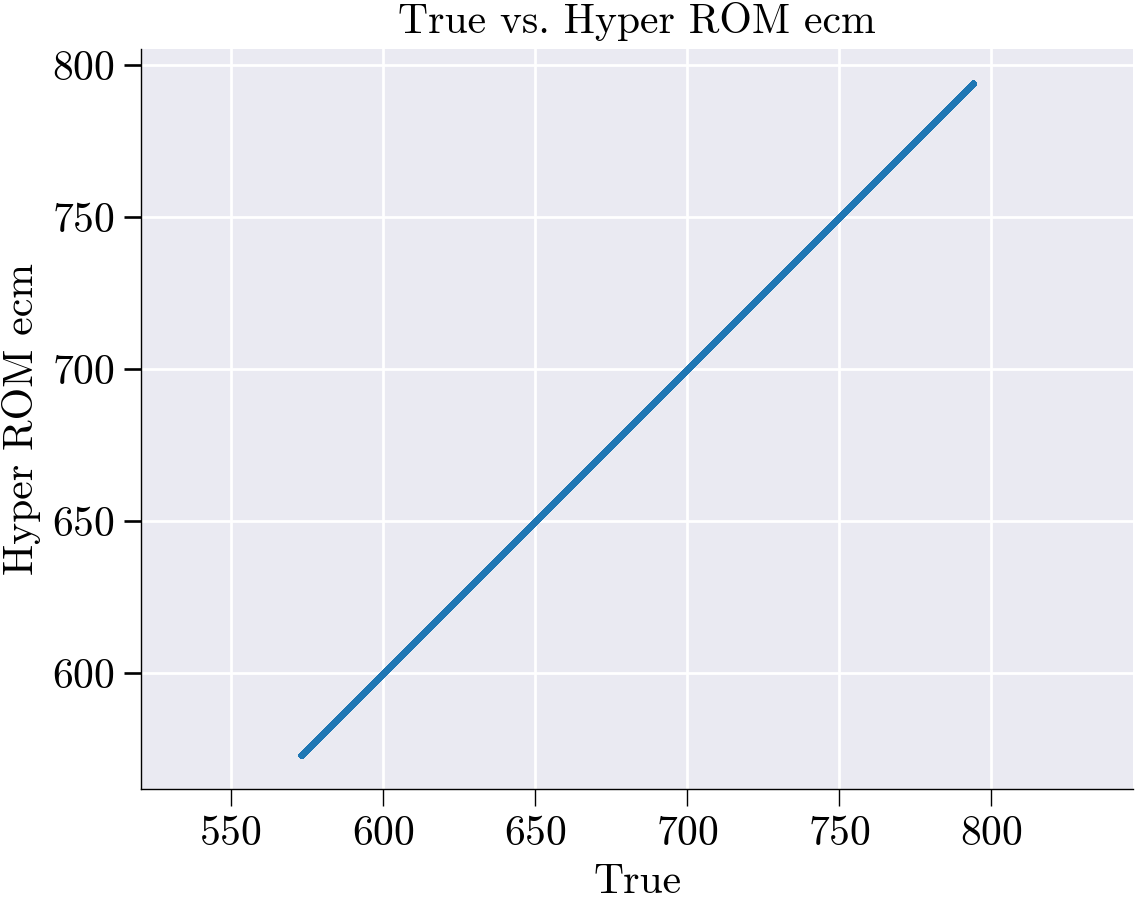

spatial_shape not given → skipping spatial snapshots.
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


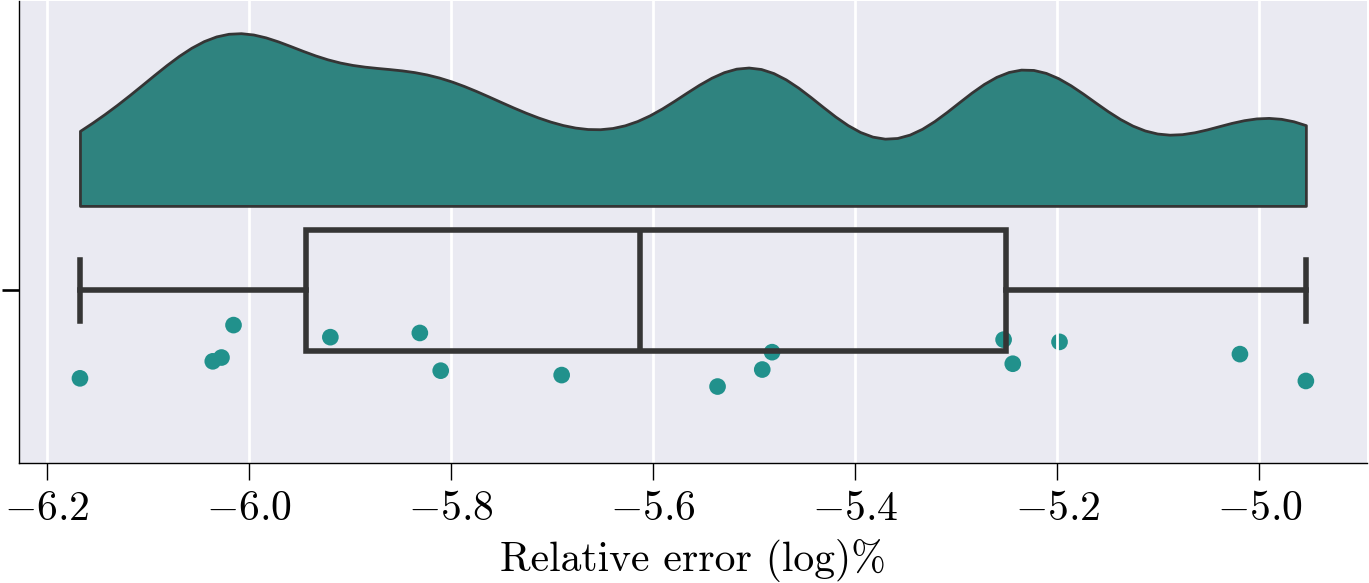

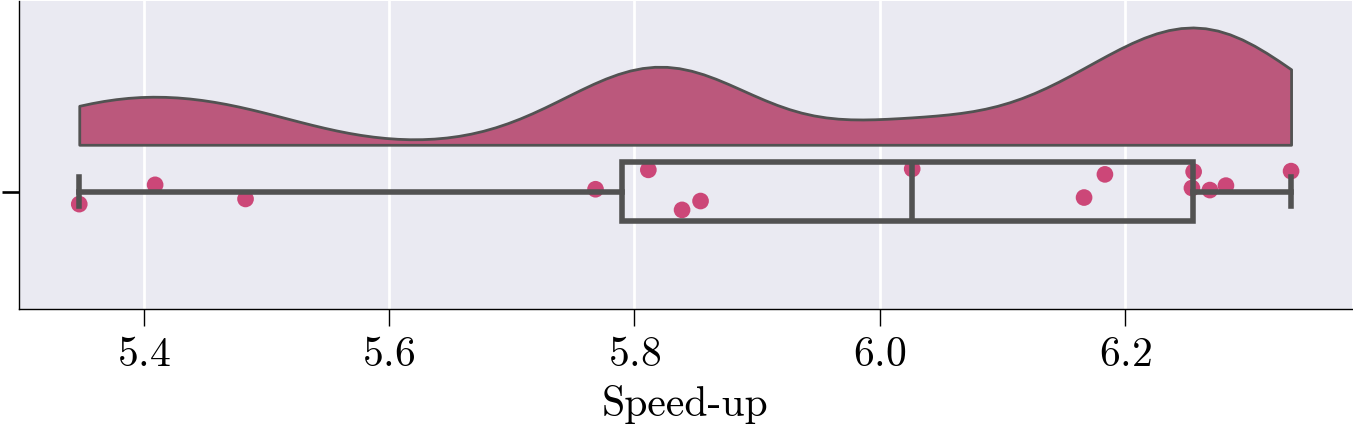

In [41]:
# --- Hyper-reduced ROM error analysis ---

# Compute a flat matrix of error metrics comparing true nonlinear solutions to hyper-ROM approximations
matrix = compute_rom_error_metrics_flat(NLS_test, NLS_hyper_rom_ecm)

# Produce a text-based report summarizing these hyper-ROM error metrics
generate_rom_error_report(matrix)

# Plot diagnostic figures: error vs. speed-up for the hyper-reduced ROM
plot_rom_error_diagnostics_flat(
    NLS_test,                   # full-order (true) solution snapshots
    NLS_hyper_rom_ecm,          # hyper-ROM-generated solution snapshots
    hyper_ROM_relative_error_ecm,   # precomputed relative error of the hyper-ROM
    hyper_ROM_speed_up_ecm,         # precomputed speed-up factor of the hyper-ROM
    sim_axis=['True', 'Hyper ROM ecm'], 
    metrics=matrix              # the matrix of error metrics just computed
)



In [42]:
# fig, ax = plot_ecsw_weights(x_nnls_m)